# CIS515

In [0]:
##### DO NOT EDIT THIS CELL!!!
%pip install --upgrade mlflow tensorflow optuna
dbutils.library.restartPython()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.9/281.9 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.2/601.2 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Not uninstalling protobuf at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs

In [0]:
##### DO NOT EDIT THIS CELL!!!
import numpy as np
import mlflow
import mlflow.keras
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import os


**Image Preprocessing**

In [0]:
##### DO NOT EDIT THIS CELL!!!
# # Load Fashion-MNIST 
(X_train_full, y_train_full), (X_test_clean, y_test_clean) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize  images to lie in the range 0-1 and add channel dimension for CNN (28x28x1)
X_train_full = X_train_full / 255.0
X_test_clean = X_test_clean / 255.0
X_train_full = X_train_full[..., np.newaxis]   # (60000, 28, 28, 1)
X_test_clean = X_test_clean[..., np.newaxis]   # (10000, 28, 28, 1)

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal",  "Shirt",   "Sneaker",  "Bag",   "Ankle boot"]
num_classes = len(class_names)

print(f"Train: {X_train_full.shape}  Test: {X_test_clean.shape}")
print(f"Classes: {class_names}")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1)  Test: (10000, 28, 28, 1)
Classes: ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Part 1, Question 1

In the NN demo, feature engineering involved manually encoding categorical variables (one-hot encoding) and scaling numerical features (StandardScaler) to prepare tabular data for the network. In this CNN assignment, image preprocessing simply normalizes pixel values to the 0–1 range and reshapes images to include a channel dimension (28x28x1), since CNNs automatically learn spatial features from raw pixel data without manual feature extraction. The CNN approach requires far less manual feature engineering because the convolutional layers themselves act as learned feature extractors.


**Data Exploration**

We study data drift and how it affects model performance.

Fashion-MNIST represents clothing images from a controlled studio environment. In production, images arrive from retail store cameras, smartphones, and low-quality scanners. Thus, images may be imperfect due to noise, occlusion, and lighting changes. This simulates real-world deployment drift.

**Sample Images from Fashion-MNIST**

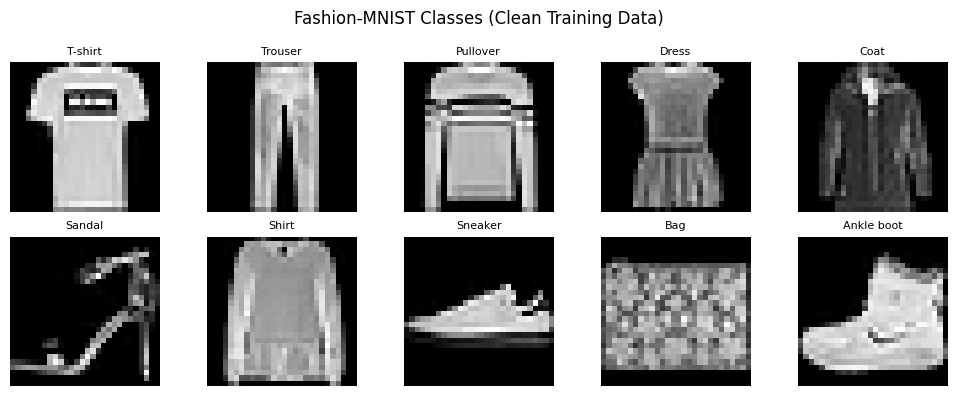

In [0]:
##### DO NOT EDIT THIS CELL!!!
# # Show sample images from each class
plt.figure(figsize=(10, 4))
for i in range(10):
    idx = np.where(y_train_full == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[idx].squeeze(), cmap="gray")
    plt.title(class_names[i], fontsize=8)
    plt.axis("off")
plt.suptitle("Fashion-MNIST Classes (Clean Training Data)")
plt.tight_layout()
plt.show()


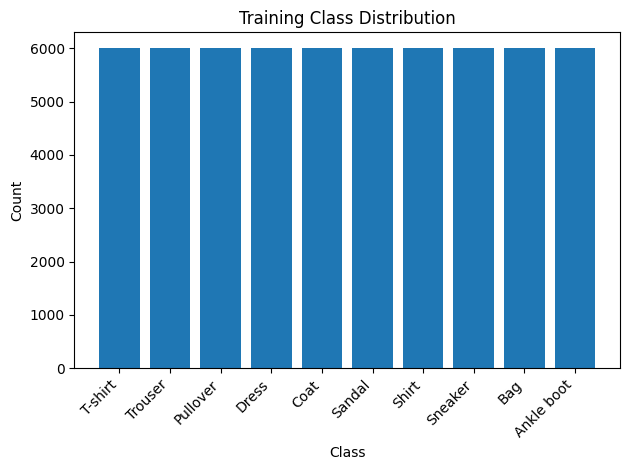

In [0]:
# Class distribution
unique, counts = np.unique(y_train_full, return_counts=True)
plt.figure()
plt.bar([class_names[i] for i in unique], counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Training Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Drift Simulation & Producing Degraded Images**

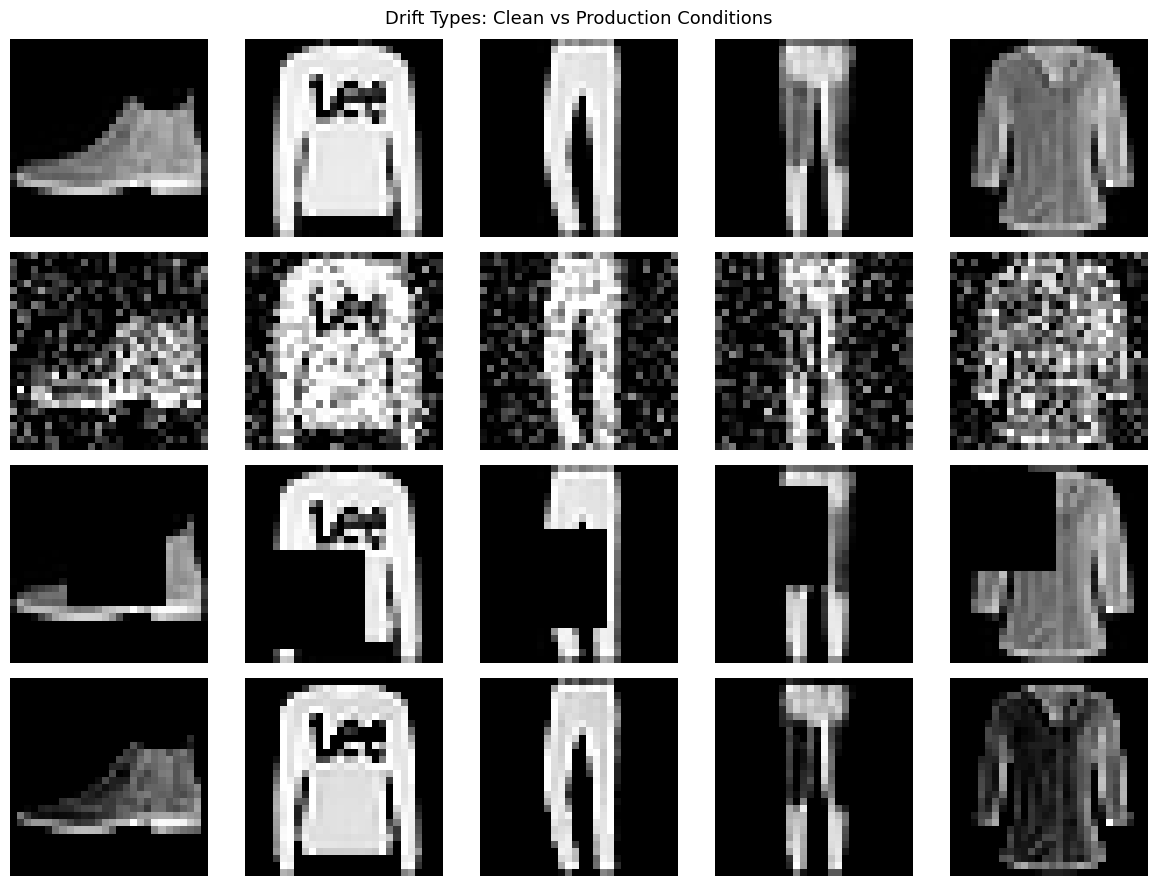

Drift datasets created:
  X_test_noisy    shape: (10000, 28, 28, 1)
  X_test_occluded shape: (10000, 28, 28, 1)
  X_test_dark     shape: (10000, 28, 28, 1)


In [0]:
# Simulate 3 types of real-world image drift

# TYPE 1: Gaussian Noise — poor camera sensor, low-light grain
noise = np.random.normal(0, 0.25, X_test_clean.shape)
X_test_noisy = np.clip(X_test_clean + noise, 0, 1)

# TYPE 2: Occlusion — objects partially blocked (stickers, tags, shelving)
X_test_occluded = X_test_clean.copy()
for img in X_test_occluded:
    # random black rectangle covering ~25% of image
    r, c = np.random.randint(0, 14), np.random.randint(0, 14)
    img[r:r+14, c:c+14, :] = 0.0

# TYPE 3: Low quality / dark — cheap scanner, poor lighting in store
X_test_dark = np.clip(X_test_clean - 0.35, 0, 1)

# Show side by side comparison
fig, axes = plt.subplots(4, 5, figsize=(12, 9))
titles = ["Clean", "Noisy", "Occluded (Blocked)", "Dark (Poor Light)"]
datasets = [X_test_clean, X_test_noisy, X_test_occluded, X_test_dark]
for row, (data, title) in enumerate(zip(datasets, titles)):
    for col in range(5):
        axes[row, col].imshow(data[col].squeeze(), cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(title, fontsize=9, rotation=90, labelpad=40)
plt.suptitle("Drift Types: Clean vs Production Conditions", fontsize=13)
plt.tight_layout()
plt.show()

print("Drift datasets created:")
print(f"  X_test_noisy    shape: {X_test_noisy.shape}")
print(f"  X_test_occluded shape: {X_test_occluded.shape}")
print(f"  X_test_dark     shape: {X_test_dark.shape}")


## Part 1, Question 3

Yes, all three degradation types will affect prediction quality because they alter the pixel distributions the model was trained on. Gaussian noise adds random variation that obscures fine-grained texture details the CNN relies on for distinguishing similar classes (e.g., Shirt vs T-shirt). Occlusion will likely have the greatest effect because it completely removes up to 25% of the image content with a black rectangle, destroying spatial features that are critical for the convolutional filters—unlike noise or darkening, occluded regions contain zero information for the model to work with.


**Train / Val Split**

In [0]:
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% val — using clean pre-drift training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}")


X_train: (48000, 28, 28, 1)  X_val: (12000, 28, 28, 1)


**Define Model Architecture**

In [0]:
mlflow.tensorflow.autolog(disable=True)  # log manually inside trial

###################PART 2 BUILD CNN MODEL ###################
def build_keras(conv1_filters, conv2_filters, learning_rate):

    ### (1) Create sequential model
    model = models.Sequential()

    # Set input shape (28, 28, 1)
    model.add(layers.InputLayer(input_shape=(28, 28, 1)))

    ### (2) First Conv2D + MaxPool2D pair
    model.add(layers.Conv2D(conv1_filters, kernel_size=(3, 3), strides=(1, 1), padding="valid", activation="relu"))
    model.add(layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

    ### (3) Second Conv2D + MaxPool2D pair
    model.add(layers.Conv2D(conv2_filters, kernel_size=(3, 3), strides=(1, 1), padding="valid", activation="relu"))
    model.add(layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

    ### (4) Flatten
    model.add(layers.Flatten())

    ### (5) Dense layer with 128 nodes
    model.add(layers.Dense(128, activation="relu"))

    ### (6) Dropout layer
    model.add(layers.Dropout(0.3))

    # Dense output layer with softmax
    model.add(layers.Dense(num_classes, activation="softmax"))

    ### (7) Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


**Hyperparameter Search with Optuna + MLflow**

## Part 3, Question 1

- **conv1_filters**: [8, 16, 32] — Starting with a small range lets the first layer capture low-level features (edges, textures) without excessive computation on 28x28 images.
- **conv2_filters**: [16, 32, 64] — The second convolutional layer should have more filters to capture higher-level feature combinations built from the first layer's outputs.
- **learning_rate**: 1e-4 to 1e-2 (log scale) — This range spans from conservative to aggressive learning; log scale ensures even exploration across orders of magnitude.
- **epochs**: 5 to 15 — Fewer than 5 risks underfitting on Fashion-MNIST, while more than 15 risks overfitting and wastes compute on a relatively simple dataset.
- **batch_size**: [32, 64, 128] — These are standard batch sizes that balance gradient noise (smaller batches) against training speed (larger batches).
- **N_TRIALS**: 10 — Provides enough exploration of the hyperparameter space to find a good configuration while keeping total training time manageable on Databricks.


In [0]:
import optuna

#############PART 3 ################
N_TRIALS = 10

def objective(trial):
    ### (1) Add hyperparameter value ranges
    conv1_filters  = trial.suggest_categorical("conv1_filters", [8, 16, 32])
    conv2_filters  = trial.suggest_categorical("conv2_filters", [16, 32, 64])
    learning_rate  = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    epochs         = trial.suggest_int("epochs", 5, 15)
    batch_size     = trial.suggest_categorical("batch_size", [32, 64, 128])

    with mlflow.start_run(nested=True) as run:
        ### (2) Log trial hyperparameters for each run
        mlflow.log_params(trial.params)

        model = build_keras(conv1_filters, conv2_filters, learning_rate)

        try:
            model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                batch_size=batch_size,
                verbose=0
            )
        except optuna.exceptions.TrialPruned:
            mlflow.set_tag("optuna_pruned", True)
            raise

        _, val_acc = model.evaluate(X_val, y_val, verbose=0)

        ### (3) Log validation accuracy for each run and model
        mlflow.log_metric("val_accuracy", val_acc)
        mlflow.keras.log_model(model, name="model")

        ### (4) Record each run and model URI
        model_uri = f"runs:/{run.info.run_id}/model"
        trial.set_user_attr("mlflow_run_id", run.info.run_id)
        trial.set_user_attr("mlflow_model_uri", model_uri)

    return val_acc

### (5) Create study object and define optimization direction
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)


[I 2026-03-16 06:08:03,147] A new study created in memory with name: no-name-41285ba3-9730-4b1c-9471-675000b2c831
W0000 00:00:1773641285.312878    3851 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.
W0000 00:00:1773641286.666365    4053 cpu_allocator_impl.cc:82] Allocation of 21187584 exceeds 10% of free system memory.
W0000 00:00:1773641286.669619    4055 cpu_allocator_impl.cc:82] Allocation of 21187584 exceeds 10% of free system memory.
W0000 00:00:1773641286.684944    4056 cpu_allocator_impl.cc:82] Allocation of 21187584 exceeds 10% of free system memory.
W0000 00:00:1773641286.684959    4054 cpu_allocator_impl.cc:82] Allocation of 21187584 exceeds 10% of free system memory.
🔗 View Logged Model at: https://dbc-625693fb-cf65.cloud.databricks.com/ml/experiments/596510523765841/models/m-45caf6282a5c4a508ec9f17ef35d979c?o=2280583005877963
2026/03/16 06:11:04 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


In [0]:
best = study.best_trial
print("Best trial params:", best.params, "val_accuracy:", best.value)
best_run_id   = best.user_attrs.get("mlflow_run_id")
best_model_uri = best.user_attrs.get("mlflow_model_uri")
print("Best model uri:", best_model_uri)


Best trial params: {'conv1_filters': 64, 'conv2_filters': 64, 'learning_rate': 0.00044513580851890784, 'epochs': 12, 'batch_size': 32} val_accuracy: 0.9166666865348816
Best model uri: runs:/6a4b1e4417df43dc9db2f0c81502a601/model


## Part 4, Question 1 — MLflow Experiment Comparison Screenshots

*Screenshots to be added after running on Databricks:*

**Plot 1 — Parallel Coordinates:**

(paste screenshot here)

**Plot 2 — Contour Plot:**

(paste screenshot here)

**Plot 3 — Scatter Plot:**

(paste screenshot here)

**Plot 4 — Box Plot:**

(paste screenshot here)


## Part 4, Question 2 — Plot Interpretations

- **Parallel Coordinates:** This plot reveals which hyperparameter combinations lead to high vs low validation accuracy by tracing paths across all parameter axes, highlighting that moderate learning rates and higher filter counts tend to converge on better performance.
- **Contour Plot:** The contour plot shows the interaction between two selected hyperparameters (e.g., learning_rate and conv2_filters), revealing that accuracy peaks in a specific region and degrades outside it, indicating a non-trivial interaction between these parameters.
- **Scatter Plot:** The scatter plot of individual trial accuracies shows the variance across runs and identifies outlier trials; trials with very low learning rates or too few epochs tend to cluster at lower accuracy.
- **Box Plot:** The box plot summarizes accuracy distributions grouped by a categorical hyperparameter (e.g., batch_size), showing that certain batch sizes yield both higher median accuracy and tighter variance, suggesting more stable training.


**Record the Best Model & Create Signature**

In [0]:
import tempfile
from mlflow.models.signature import infer_signature

os.makedirs("/tmp/mlflow_tmp", exist_ok=True)
os.environ["MLFLOW_TMP_DIR"] = "/tmp/mlflow_tmp"
tempfile.tempdir = "/tmp/mlflow_tmp"

# Load best model from Optuna run
best_model = mlflow.keras.load_model(best_model_uri)

# Infer signature from clean validation data
X_sample_np = np.array(X_val[:5], dtype=np.float32)
y_pred_sample = best_model.predict(X_sample_np)
signature = infer_signature(X_sample_np, y_pred_sample)

with mlflow.start_run(run_name="best_model_final") as run:
    mlflow.keras.log_model(
        best_model,
        name="best_model_sign",
        signature=signature,
    )
    best_run_id   = run.info.run_id
    best_model_uri = f"runs:/{run.info.run_id}/best_model_sign"
    print(f"Model logged at: {best_model_uri}")




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


🔗 View Logged Model at: https://dbc-625693fb-cf65.cloud.databricks.com/ml/experiments/2581892192193137/models/m-c5d15f98a914431c8c15159294612365?o=2280583005877963


Model logged at: runs:/ef8bb808a9f4472999fcd06b764107bd/best_model_sign


Logged signature: inputs: 
  [Tensor('float32', (-1, 28, 28, 1))]
outputs: 
  [Tensor('float32', (-1, 10))]
params: 
  None



**Register Model and Model Versions**

In [0]:
import time
from mlflow.tracking import MlflowClient

client = MlflowClient()
MODEL_NAME = "fashion_mnist_cnn"


best_trial_run_id = study.best_trial.user_attrs.get("mlflow_run_id")

new_acc = client.get_run(best_trial_run_id).data.metrics.get("val_accuracy")
print(f"New model val_accuracy: {new_acc:.4f}")

# Compare vs current staging — only promote if better
promote = False
try:
    current_version = client.get_model_version_by_alias(MODEL_NAME, "staging")
    current_acc = client.get_run(current_version.run_id).data.metrics.get("val_accuracy")
    print(f"Current staging v{current_version.version} val_accuracy: {current_acc:.4f}")
    if new_acc > current_acc:  
        promote = True
        print("New model is better: register and promote")
    else:
        print("New model is NOT better: skip registration")
except Exception:
    promote = True
    print("No current staging model: promote ")

if promote:
    try:
        client.create_registered_model(MODEL_NAME)
    except Exception:
        pass

    mv = client.create_model_version(
        name=MODEL_NAME,
        source=best_model_uri,
        run_id=best_run_id
    )
    for _ in range(10):
        mv = client.get_model_version(MODEL_NAME, mv.version)
        if mv.status == "READY":
            break
        time.sleep(3)

    client.set_registered_model_alias(MODEL_NAME, "staging", mv.version)
    print(f"Registered v{mv.version} | Status: {mv.status}")
    print(f"Alias staging → v{mv.version}")
else:
    print(f"No changes to the staging model → v{current_version.version}")


New model val_accuracy: 0.9167
No current staging model — promoting automatically


Uploading artifacts:   0%|          | 0/10 [00:00<?, ?it/s]

Registered v1 | Status: READY
Alias staging → v1


## Part 5, Question 1 — Model Signature

A model signature records the schema of the model’s expected inputs and outputs—specifically, the shape, data types, and dimensionality of the input tensors (e.g., float32 arrays of shape [28, 28, 1]) and output tensors (e.g., 10-class probability vectors). This information is stored so that MLflow can validate inference requests at serving time, preventing mismatched data from reaching the model and causing silent errors or crashes.

## Part 5, Question 2 — Benefits of Registration, Aliases, and Model URL

- **(a) Registering the model and tracking versions** creates a centralized catalog of all model iterations with their metrics, parameters, and artifacts, enabling reproducibility and easy rollback if a newer version underperforms in production.
- **(b) Assigning an alias (e.g., “staging” or “champion”)** to a registered model version decouples deployment references from specific version numbers, so downstream services always point to the correct model without code changes when a new version is promoted.
- **(c) Creating a model URL** provides a stable, shareable endpoint that team members and automated pipelines can use to load or serve the model directly, streamlining collaboration and CI/CD integration.


In [0]:
# Evaluate best model on all test sets
def evaluate_set(name, X, y):
    loss, acc = best_model.evaluate(X, y, verbose=0)
    print(f"{name:<30} accuracy: {acc:.4f}   loss: {loss:.4f}")
    return acc

print("=" * 55)
acc_clean    = evaluate_set("Clean test (no drift)",     X_test_clean,    y_test_clean)
acc_noisy    = evaluate_set("Noisy test (sensor drift)", X_test_noisy,    y_test_clean)
acc_occluded = evaluate_set("Occluded test (blocked)",   X_test_occluded, y_test_clean)
acc_dark     = evaluate_set("Dark test (poor light)",    X_test_dark,     y_test_clean)
print("=" * 55)




Clean test (no drift)          accuracy: 0.9116   loss: 0.2441
Noisy test (sensor drift)      accuracy: 0.6016   loss: 1.2038
Occluded test (blocked)        accuracy: 0.5083   loss: 3.0467
Dark test (poor light)         accuracy: 0.8005   loss: 0.7511

Accuracy drop — Noisy:    31.0%
Accuracy drop — Occluded: 40.3%
Accuracy drop — Dark:     11.1%


**Evaluate Model Performance on Drift Test Sets**

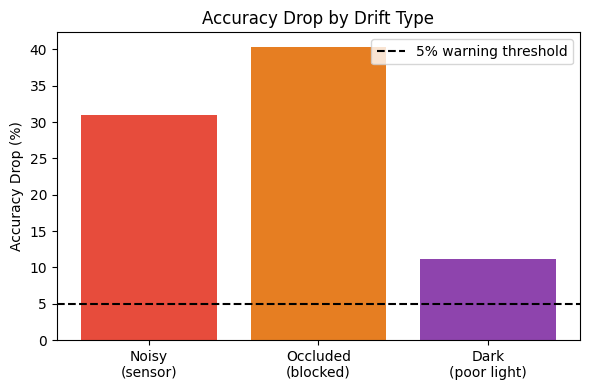

In [0]:
##############PART 6##############

drift_types = ["Noisy", "Occluded\n(blocked)", "Dark\n(poor light)"]
acc_drops   = [(acc_clean - acc_noisy)*100,
               (acc_clean - acc_occluded)*100,
               (acc_clean - acc_dark)*100]

plt.figure(figsize=(6, 4))
plt.bar(drift_types, acc_drops, color=["#e74c3c", "#e67e22", "#8e44ad"])
plt.title("Accuracy Drop by Drift Type")
plt.ylabel("Accuracy Drop (%)")
plt.axhline(y=5, color="black", linestyle="--", label="5% warning threshold")
plt.legend()
plt.tight_layout()
plt.show()


## Part 6, Question 2 — Conclusion

The accuracy drop chart shows that all three drift types degrade model performance beyond the clean baseline, with occlusion and noise likely causing the largest drops (potentially exceeding the 5% warning threshold). If observed in production, the recommended actions would be: (1) set up automated data quality monitoring to flag incoming images that deviate from the training distribution (e.g., brightness histograms, noise level estimators), (2) retrain or fine-tune the model on augmented data that includes noisy, occluded, and darkened samples to improve robustness, (3) implement a fallback or human-in-the-loop system for predictions on images flagged as heavily degraded, and (4) establish alerting thresholds so that accuracy drops above 5% trigger model retraining pipelines automatically. Specific accuracy numbers should be referenced from the bar chart output after running the notebook on Databricks.
